
# BTC/USDT 1-Hour Realized-Volatility Forecasting

This notebook implements the interview project end-to-end:

\[
\text{5-minute BTCUSDT data}
\rightarrow
\text{1-hour forward realized volatility}
\rightarrow
\text{historical + microstructure + derivatives features}
\rightarrow
\text{purged walk-forward validation}
\]

Models:
1. historical-volatility persistence baseline;
2. Ridge regression;
3. gradient-boosted trees;
4. a small PyTorch MLP.

Diagnostics:
- feature-group ablation;
- volatility-regime analysis;
- RMSE / MAE / QLIKE;
- illustrative volatility-targeted position sizing with turnover and transaction costs.

## Important research-design choices

- Instrument: **Binance USD-M BTCUSDT perpetual futures**.
- Each completed 5-minute bar is timestamped at its **bar end**, so features at time \(t\) use only information observable at \(t\).
- Target:
  \[
  RV_{t,t+1h}=\sqrt{\sum_{j=1}^{12}r_{t+j}^{2}}.
  \]
- Forward labels overlap, so every train/test boundary is **purged by at least 12 bars**.
- Funding and open interest are aligned **backward/as-of**: never backfill future information.
- Default microstructure source is historical `bookDepth`, using the \(-1\%\) and \(+1\%\) depth bands to form an imbalance. This is an aggregated depth-band OBI, **not** exact top-of-book OBI.
- An optional `bookTicker` loader is included for exact best-bid/best-ask imbalance, but the raw files are much larger.

The notebook intentionally does **not** hard-code any claimed model ranking. Run it and report the results it actually produces.


In [1]:

# Optional: uncomment if your environment is missing packages.
# %pip install -q pandas numpy requests scikit-learn matplotlib torch

from __future__ import annotations

import math
import zipfile
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
if TORCH_AVAILABLE:
    torch.manual_seed(RANDOM_SEED)

print("PyTorch available:", TORCH_AVAILABLE)


PyTorch available: True



## 1. Configuration

The default 3-month sample is large enough for a real walk-forward experiment while remaining manageable on a laptop.

For a quick smoke test, shorten the date range to one month and set `N_SPLITS=2`.

`MICROSTRUCTURE_SOURCE="bookDepth"` is recommended for the first run because it is much lighter than raw `bookTicker`.

If Binance Vision is unavailable from your network, manually download the same ZIP filenames into `CACHE_DIR`; the loaders will reuse cached files.


In [2]:

SYMBOL = "BTCUSDT"
START_DATE = "2025-01-01"
END_DATE   = "2025-03-31"

CACHE_DIR = Path("./btc_vol_project_data")
OUTPUT_DIR = Path("./btc_vol_project_outputs")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MICROSTRUCTURE_SOURCE = "bookDepth"   # "bookDepth", "bookTicker", or None
REQUIRE_MICROSTRUCTURE = False

N_SPLITS = 5
TEST_DAYS = 10
MIN_TRAIN_DAYS = 30
PURGE_BARS = 12                      # 12 x 5m = 1 hour

RUN_MLP = True
RIDGE_ALPHA = 10.0

GBT_PARAMS = dict(
    learning_rate=0.05,
    max_iter=250,
    max_leaf_nodes=15,
    min_samples_leaf=50,
    l2_regularization=1.0,
    random_state=RANDOM_SEED,
)

MLP_MAX_EPOCHS = 40
MLP_PATIENCE = 5
MLP_BATCH_SIZE = 1024
MLP_LR = 1e-3

TRANSACTION_COST_BPS = 3.0
MAX_LEVERAGE = 2.0

BINANCE_VISION = "https://data.binance.vision/data/futures/um"


## 2. Download/cache helpers

In [3]:

def _download(url: str, path: Path, timeout: int = 60) -> Path:
    """Download once and cache locally."""
    if path.exists() and path.stat().st_size > 0:
        return path

    path.parent.mkdir(parents=True, exist_ok=True)
    print("Downloading:", url)
    with requests.get(url, stream=True, timeout=timeout) as r:
        r.raise_for_status()
        with open(path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
    return path


def _read_first_csv_from_zip(path: Path, header="infer") -> pd.DataFrame:
    with zipfile.ZipFile(path) as zf:
        members = [m for m in zf.namelist() if m.lower().endswith(".csv")]
        if not members:
            raise ValueError(f"No CSV found inside {path}")
        with zf.open(members[0]) as f:
            return pd.read_csv(f, header=header)


def _month_periods(start_date: str, end_date: str):
    return pd.period_range(pd.Timestamp(start_date), pd.Timestamp(end_date), freq="M")


def _days(start_date: str, end_date: str):
    return pd.date_range(start_date, end_date, freq="D")


KLINE_COLUMNS = [
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_volume", "n_trades",
    "taker_buy_base", "taker_buy_quote", "ignore"
]


def _read_kline_zip(path: Path) -> pd.DataFrame:
    raw = _read_first_csv_from_zip(path, header=None)
    first = str(raw.iloc[0, 0]).lower()
    if "open" in first and "time" in first:
        raw = raw.iloc[1:].reset_index(drop=True)
    if raw.shape[1] < 12:
        raise ValueError(f"Unexpected kline schema in {path}: {raw.shape}")
    raw = raw.iloc[:, :12]
    raw.columns = KLINE_COLUMNS
    return raw


def _to_utc_from_epoch_maybe(series: pd.Series) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce")
    med = x.dropna().median()
    unit = "us" if med > 1e14 else "ms"
    return pd.to_datetime(x, unit=unit, utc=True, errors="coerce")



## 3. Load 5-minute BTCUSDT perpetual-futures bars

The archive stores 5-minute candles. The feature timestamp is the **end of the completed bar**, so a 10:00–10:05 candle becomes usable at about 10:05.


In [4]:

def load_klines(symbol: str, start_date: str, end_date: str) -> pd.DataFrame:
    parts = []
    for p in _month_periods(start_date, end_date):
        ym = str(p)
        fname = f"{symbol}-5m-{ym}.zip"
        url = f"{BINANCE_VISION}/monthly/klines/{symbol}/5m/{fname}"
        path = CACHE_DIR / "klines" / fname
        try:
            _download(url, path)
            parts.append(_read_kline_zip(path))
        except Exception as e:
            warnings.warn(f"Kline month {ym} skipped: {e}")

    if not parts:
        raise RuntimeError("No kline data loaded.")

    df = pd.concat(parts, ignore_index=True)
    for c in ["open","high","low","close","volume","quote_volume",
              "n_trades","taker_buy_base","taker_buy_quote"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    open_ts = _to_utc_from_epoch_maybe(df["open_time"])
    df["timestamp"] = open_ts + pd.Timedelta(minutes=5)

    start = pd.Timestamp(start_date, tz="UTC")
    end_exclusive = pd.Timestamp(end_date, tz="UTC") + pd.Timedelta(days=1)
    df = (
        df[(df["timestamp"] >= start) & (df["timestamp"] < end_exclusive)]
        .sort_values("timestamp")
        .drop_duplicates("timestamp", keep="last")
        .set_index("timestamp")
    )
    return df


klines = load_klines(SYMBOL, START_DATE, END_DATE)
print(klines.shape)
display(klines.head())
display(klines.tail())


Downloading: https://data.binance.vision/data/futures/um/monthly/klines/BTCUSDT/5m/BTCUSDT-5m-2025-01.zip
Downloading: https://data.binance.vision/data/futures/um/monthly/klines/BTCUSDT/5m/BTCUSDT-5m-2025-02.zip
Downloading: https://data.binance.vision/data/futures/um/monthly/klines/BTCUSDT/5m/BTCUSDT-5m-2025-03.zip
(25919, 12)


,open_time,open,high,low,close,volume,close_time,quote_volume,n_trades,taker_buy_base,taker_buy_quote,ignore
timestamp,,,,,,,,,,,,
2025-01-01 00:05:00+00:00,1735689600000,93548.8,93690.0,93514.2,93648.4,341.604,1735689899999,3.198260e+07,8176,148.318,1.388557e+07,0
2025-01-01 00:10:00+00:00,1735689900000,93648.3,93666.7,93576.9,93585.9,166.341,1735690199999,1.557057e+07,4688,82.529,7.724998e+06,0
2025-01-01 00:15:00+00:00,1735690200000,93586.0,93637.2,93460.2,93631.2,480.204,1735690499999,4.490886e+07,9464,141.094,1.319648e+07,0
2025-01-01 00:20:00+00:00,1735690500000,93631.2,93829.4,93588.0,93781.0,545.647,1735690799999,5.114925e+07,11216,330.415,3.097547e+07,0
2025-01-01 00:25:00+00:00,1735690800000,93781.0,93885.0,93680.0,93712.0,392.042,1735691099999,3.676516e+07,7673,204.949,1.922038e+07,0


,open_time,open,high,low,close,volume,close_time,quote_volume,n_trades,taker_buy_base,taker_buy_quote,ignore
timestamp,,,,,,,,,,,,
2025-03-31 23:35:00+00:00,1743463800000,82317.4,82397.1,82242.4,82388.1,379.391,1743464099999,3.122763e+07,7970,209.866,1.727570e+07,0
2025-03-31 23:40:00+00:00,1743464100000,82388.1,82511.5,82388.1,82444.0,357.747,1743464399999,2.949834e+07,7143,183.262,1.511114e+07,0
2025-03-31 23:45:00+00:00,1743464400000,82444.0,82472.5,82409.1,82436.1,160.519,1743464699999,1.323435e+07,4254,97.474,8.036347e+06,0
2025-03-31 23:50:00+00:00,1743464700000,82436.0,82444.0,82355.3,82379.3,190.698,1743464999999,1.571050e+07,4321,104.046,8.571431e+06,0
2025-03-31 23:55:00+00:00,1743465000000,82379.3,82525.1,82365.9,82525.1,223.971,1743465299999,1.846784e+07,5269,165.975,1.368714e+07,0



## 4. Load funding rate

Funding is lower-frequency than the 5-minute master clock. It is later aligned with `merge_asof(..., direction="backward")`, so a forecast can use only the latest already-observed funding value.


In [5]:

def load_funding(symbol: str, start_date: str, end_date: str) -> pd.DataFrame:
    parts = []
    for p in _month_periods(start_date, end_date):
        ym = str(p)
        fname = f"{symbol}-fundingRate-{ym}.zip"
        url = f"{BINANCE_VISION}/monthly/fundingRate/{symbol}/{fname}"
        path = CACHE_DIR / "fundingRate" / fname
        try:
            _download(url, path)
            parts.append(_read_first_csv_from_zip(path, header="infer"))
        except Exception as e:
            warnings.warn(f"Funding month {ym} skipped: {e}")

    if not parts:
        return pd.DataFrame(columns=["funding_rate"], index=pd.DatetimeIndex([], tz="UTC"))

    df = pd.concat(parts, ignore_index=True)
    cols = {str(c).lower(): c for c in df.columns}

    time_col = next((cols[k] for k in ["calc_time","fundingtime","funding_time","time"] if k in cols), None)
    rate_col = next((cols[k] for k in ["last_funding_rate","fundingrate","funding_rate"] if k in cols), None)

    if time_col is None or rate_col is None:
        if df.shape[1] >= 3:
            warnings.warn("Funding schema not recognized by name; assuming first column=time, last column=rate.")
            time_col, rate_col = df.columns[0], df.columns[-1]
        else:
            raise ValueError(f"Unrecognized funding schema: {df.columns.tolist()}")

    ts_num = pd.to_numeric(df[time_col], errors="coerce")
    if ts_num.notna().mean() > 0.8:
        ts = _to_utc_from_epoch_maybe(ts_num)
    else:
        ts = pd.to_datetime(df[time_col], utc=True, errors="coerce")

    out = pd.DataFrame({
        "timestamp": ts,
        "funding_rate": pd.to_numeric(df[rate_col], errors="coerce"),
    }).dropna().sort_values("timestamp").drop_duplicates("timestamp", keep="last")

    return out.set_index("timestamp")


funding = load_funding(SYMBOL, START_DATE, END_DATE)
print(funding.shape)
display(funding.head())


Downloading: https://data.binance.vision/data/futures/um/monthly/fundingRate/BTCUSDT/BTCUSDT-fundingRate-2025-01.zip
Downloading: https://data.binance.vision/data/futures/um/monthly/fundingRate/BTCUSDT/BTCUSDT-fundingRate-2025-02.zip
Downloading: https://data.binance.vision/data/futures/um/monthly/fundingRate/BTCUSDT/BTCUSDT-fundingRate-2025-03.zip
(270, 1)


,funding_rate
timestamp,
2025-01-01 00:00:00.015000+00:00,0.0001
2025-01-01 08:00:00+00:00,0.0001
2025-01-01 16:00:00.001000+00:00,0.0001
2025-01-02 00:00:00+00:00,0.0001
2025-01-02 08:00:00.006000+00:00,0.0001



## 5. Load futures metrics / Open Interest

Binance Vision `metrics` files include venue aggregates such as `sum_open_interest` and `sum_open_interest_value`.  
The notebook uses OI value and constructs short-horizon percentage changes.


In [6]:

def load_metrics(symbol: str, start_date: str, end_date: str) -> pd.DataFrame:
    parts, missing = [], 0

    for d in _days(start_date, end_date):
        ds = d.strftime("%Y-%m-%d")
        fname = f"{symbol}-metrics-{ds}.zip"
        url = f"{BINANCE_VISION}/daily/metrics/{symbol}/{fname}"
        path = CACHE_DIR / "metrics" / fname
        try:
            _download(url, path)
            parts.append(_read_first_csv_from_zip(path, header="infer"))
        except Exception:
            missing += 1

    if not parts:
        return pd.DataFrame(
            columns=["open_interest", "open_interest_value"],
            index=pd.DatetimeIndex([], tz="UTC"),
        )

    if missing:
        warnings.warn(f"Metrics: {missing} daily files unavailable.")

    df = pd.concat(parts, ignore_index=True)
    required = {"create_time", "sum_open_interest", "sum_open_interest_value"}
    if not required.issubset(df.columns):
        raise ValueError(f"Unexpected metrics columns: {df.columns.tolist()}")

    out = pd.DataFrame({
        "timestamp": pd.to_datetime(df["create_time"], utc=True, errors="coerce"),
        "open_interest": pd.to_numeric(df["sum_open_interest"], errors="coerce"),
        "open_interest_value": pd.to_numeric(df["sum_open_interest_value"], errors="coerce"),
    }).dropna(subset=["timestamp"]).sort_values("timestamp")

    return out.drop_duplicates("timestamp", keep="last").set_index("timestamp")


metrics = load_metrics(SYMBOL, START_DATE, END_DATE)
print(metrics.shape)
display(metrics.head())


Downloading: https://data.binance.vision/data/futures/um/daily/metrics/BTCUSDT/BTCUSDT-metrics-2025-01-01.zip
Downloading: https://data.binance.vision/data/futures/um/daily/metrics/BTCUSDT/BTCUSDT-metrics-2025-01-02.zip
Downloading: https://data.binance.vision/data/futures/um/daily/metrics/BTCUSDT/BTCUSDT-metrics-2025-01-03.zip
Downloading: https://data.binance.vision/data/futures/um/daily/metrics/BTCUSDT/BTCUSDT-metrics-2025-01-04.zip
Downloading: https://data.binance.vision/data/futures/um/daily/metrics/BTCUSDT/BTCUSDT-metrics-2025-01-05.zip
Downloading: https://data.binance.vision/data/futures/um/daily/metrics/BTCUSDT/BTCUSDT-metrics-2025-01-06.zip
Downloading: https://data.binance.vision/data/futures/um/daily/metrics/BTCUSDT/BTCUSDT-metrics-2025-01-07.zip
Downloading: https://data.binance.vision/data/futures/um/daily/metrics/BTCUSDT/BTCUSDT-metrics-2025-01-08.zip
Downloading: https://data.binance.vision/data/futures/um/daily/metrics/BTCUSDT/BTCUSDT-metrics-2025-01-09.zip
Downloadin

,open_interest,open_interest_value
timestamp,,
2025-01-01 00:00:00+00:00,91253.336,8.545729e+09
2025-01-01 00:05:00+00:00,91236.202,8.538845e+09
2025-01-01 00:10:00+00:00,91336.316,8.552122e+09
2025-01-01 00:15:00+00:00,91308.036,8.562959e+09
2025-01-01 00:20:00+00:00,91299.112,8.556002e+09



## 6. Microstructure data

### Default: `bookDepth`

Use the \(-1\%\) and \(+1\%\) depth bands:

\[
OBI^{1\%}_t=
\frac{D^{bid,1\%}_t-D^{ask,1\%}_t}
{D^{bid,1\%}_t+D^{ask,1\%}_t}.
\]

This is a **depth-band imbalance**.

### Optional: `bookTicker`

Use best-bid and best-ask quantities:

\[
OBI^{top}_t=
\frac{Q^{bid}_t-Q^{ask}_t}{Q^{bid}_t+Q^{ask}_t}.
\]

This is closer to the top-of-book OBI discussed in the interview, but raw files are much heavier.


In [7]:

def load_bookdepth_5m(symbol: str, start_date: str, end_date: str) -> pd.DataFrame:
    daily_parts, missing = [], 0

    for d in _days(start_date, end_date):
        ds = d.strftime("%Y-%m-%d")
        fname = f"{symbol}-bookDepth-{ds}.zip"
        url = f"{BINANCE_VISION}/daily/bookDepth/{symbol}/{fname}"
        path = CACHE_DIR / "bookDepth" / fname

        try:
            _download(url, path)
            x = _read_first_csv_from_zip(path, header="infer")
            needed = {"timestamp", "percentage", "depth"}
            if not needed.issubset(x.columns):
                raise ValueError(f"Unexpected bookDepth columns: {x.columns.tolist()}")

            x["timestamp"] = pd.to_datetime(x["timestamp"], utc=True, errors="coerce")
            x["percentage"] = pd.to_numeric(x["percentage"], errors="coerce")
            x["depth"] = pd.to_numeric(x["depth"], errors="coerce")
            x = x.dropna(subset=["timestamp", "percentage", "depth"])
            x = x[x["percentage"].isin([-1, 1])]

            if x.empty:
                continue

            wide = x.pivot_table(
                index="timestamp", columns="percentage", values="depth", aggfunc="last"
            ).rename(columns={-1: "bid_depth_1pct", 1: "ask_depth_1pct"})

            if not {"bid_depth_1pct", "ask_depth_1pct"}.issubset(wide.columns):
                continue

            denom = wide["bid_depth_1pct"] + wide["ask_depth_1pct"]
            wide["obi"] = (
                (wide["bid_depth_1pct"] - wide["ask_depth_1pct"])
                / denom.replace(0, np.nan)
            )
            wide["abs_obi"] = wide["obi"].abs()
            wide["total_depth"] = denom

            five = wide[
                ["bid_depth_1pct", "ask_depth_1pct", "obi", "abs_obi", "total_depth"]
            ].resample("5min", label="right", closed="right").mean()

            daily_parts.append(five)

        except Exception:
            missing += 1

    if not daily_parts:
        return pd.DataFrame(index=pd.DatetimeIndex([], tz="UTC"))

    if missing:
        warnings.warn(f"bookDepth: {missing} daily files unavailable.")

    out = pd.concat(daily_parts).sort_index()
    return out[~out.index.duplicated(keep="last")]


def load_bookticker_5m(symbol: str, start_date: str, end_date: str) -> pd.DataFrame:
    daily_parts, missing = [], 0

    expected = [
        "update_id", "best_bid_price", "best_bid_qty",
        "best_ask_price", "best_ask_qty",
        "transaction_time", "event_time",
    ]

    for d in _days(start_date, end_date):
        ds = d.strftime("%Y-%m-%d")
        fname = f"{symbol}-bookTicker-{ds}.zip"
        url = f"{BINANCE_VISION}/daily/bookTicker/{symbol}/{fname}"
        path = CACHE_DIR / "bookTicker" / fname

        try:
            _download(url, path)
            x = _read_first_csv_from_zip(path, header="infer")

            req = {"best_bid_price","best_bid_qty","best_ask_price","best_ask_qty"}
            if not req.issubset(x.columns):
                raw = _read_first_csv_from_zip(path, header=None)
                if raw.shape[1] < 7:
                    raise ValueError("Unexpected bookTicker schema")
                raw = raw.iloc[:, :7]
                raw.columns = expected
                if str(raw.iloc[0, 0]).lower() == "update_id":
                    raw = raw.iloc[1:].reset_index(drop=True)
                x = raw

            for c in ["best_bid_price","best_bid_qty","best_ask_price","best_ask_qty",
                      "transaction_time","event_time"]:
                x[c] = pd.to_numeric(x[c], errors="coerce")

            x["timestamp"] = _to_utc_from_epoch_maybe(x["event_time"])
            x = x.dropna(subset=["timestamp"]).sort_values(["timestamp", "update_id"])

            bid_q = x["best_bid_qty"]
            ask_q = x["best_ask_qty"]
            denom = bid_q + ask_q

            x["obi"] = (bid_q - ask_q) / denom.replace(0, np.nan)
            x["abs_obi"] = x["obi"].abs()
            x["mid"] = (x["best_bid_price"] + x["best_ask_price"]) / 2
            x["spread"] = (
                (x["best_ask_price"] - x["best_bid_price"])
                / x["mid"].replace(0, np.nan)
            )
            x["total_depth"] = denom

            five = x.set_index("timestamp")[
                ["obi", "abs_obi", "spread", "total_depth"]
            ].resample("5min", label="right", closed="right").mean()

            daily_parts.append(five)

        except Exception:
            missing += 1

    if not daily_parts:
        return pd.DataFrame(index=pd.DatetimeIndex([], tz="UTC"))

    if missing:
        warnings.warn(f"bookTicker: {missing} daily files unavailable.")

    out = pd.concat(daily_parts).sort_index()
    return out[~out.index.duplicated(keep="last")]


if MICROSTRUCTURE_SOURCE == "bookDepth":
    micro = load_bookdepth_5m(SYMBOL, START_DATE, END_DATE)
elif MICROSTRUCTURE_SOURCE == "bookTicker":
    micro = load_bookticker_5m(SYMBOL, START_DATE, END_DATE)
else:
    micro = pd.DataFrame(index=pd.DatetimeIndex([], tz="UTC"))

print("Microstructure source:", MICROSTRUCTURE_SOURCE, "shape:", micro.shape)
display(micro.head())

if REQUIRE_MICROSTRUCTURE and micro.empty:
    raise RuntimeError("Microstructure data required but none were loaded.")


Downloading: https://data.binance.vision/data/futures/um/daily/bookDepth/BTCUSDT/BTCUSDT-bookDepth-2025-01-01.zip
Downloading: https://data.binance.vision/data/futures/um/daily/bookDepth/BTCUSDT/BTCUSDT-bookDepth-2025-01-02.zip
Downloading: https://data.binance.vision/data/futures/um/daily/bookDepth/BTCUSDT/BTCUSDT-bookDepth-2025-01-03.zip
Downloading: https://data.binance.vision/data/futures/um/daily/bookDepth/BTCUSDT/BTCUSDT-bookDepth-2025-01-04.zip
Downloading: https://data.binance.vision/data/futures/um/daily/bookDepth/BTCUSDT/BTCUSDT-bookDepth-2025-01-05.zip
Downloading: https://data.binance.vision/data/futures/um/daily/bookDepth/BTCUSDT/BTCUSDT-bookDepth-2025-01-06.zip
Downloading: https://data.binance.vision/data/futures/um/daily/bookDepth/BTCUSDT/BTCUSDT-bookDepth-2025-01-07.zip
Downloading: https://data.binance.vision/data/futures/um/daily/bookDepth/BTCUSDT/BTCUSDT-bookDepth-2025-01-08.zip
Downloading: https://data.binance.vision/data/futures/um/daily/bookDepth/BTCUSDT/BTCUSDT

/var/folders/tg/vz3wxr494lv6shgrrn3smtt40000gn/T/ipykernel_75642/2375833306.py:54: UserWarning: bookDepth: 55 daily files unavailable.
  warnings.warn(f"bookDepth: {missing} daily files unavailable.")


percentage,bid_depth_1pct,ask_depth_1pct,obi,abs_obi,total_depth
timestamp,,,,,
2025-01-01 00:05:00+00:00,1825.2370,1087.4127,0.253992,0.253992,2912.6497
2025-01-01 00:10:00+00:00,1873.1318,1098.3648,0.260726,0.260726,2971.4966
2025-01-01 00:15:00+00:00,1949.1641,1059.5210,0.295633,0.295633,3008.6851
2025-01-01 00:20:00+00:00,1814.1111,1096.2537,0.246617,0.246617,2910.3648
2025-01-01 00:25:00+00:00,1795.9341,1098.0233,0.241082,0.241082,2893.9574



## 7. Align all information sets without look-ahead

- Klines define the 5-minute master clock.
- Funding and OI are joined **backward** in time.
- Microstructure is already aggregated to completed 5-minute intervals.


In [8]:

def asof_join(left: pd.DataFrame, right: pd.DataFrame, tolerance: pd.Timedelta) -> pd.DataFrame:
    if right.empty:
        return left.copy()

    l = left.reset_index().sort_values("timestamp")
    r = right.reset_index().sort_values("timestamp")
    out = pd.merge_asof(
        l, r, on="timestamp", direction="backward", tolerance=tolerance
    )
    return out.set_index("timestamp")


data = klines.copy()
data = asof_join(data, funding, pd.Timedelta(hours=12))
data = asof_join(data, metrics, pd.Timedelta(minutes=20))

if not micro.empty:
    data = data.join(micro, how="left")

print(data.shape)
display(data.head(15))


(25919, 20)


,open_time,open,high,low,close,volume,close_time,quote_volume,n_trades,taker_buy_base,taker_buy_quote,ignore,funding_rate,open_interest,open_interest_value,bid_depth_1pct,ask_depth_1pct,obi,abs_obi,total_depth
timestamp,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:05:00+00:00,1735689600000,93548.8,93690.0,93514.2,93648.4,341.604,1735689899999,3.198260e+07,8176,148.318,1.388557e+07,0,0.0001,91236.202,8.538845e+09,1825.237000,1087.412700,0.253992,0.253992,2912.649700
2025-01-01 00:10:00+00:00,1735689900000,93648.3,93666.7,93576.9,93585.9,166.341,1735690199999,1.557057e+07,4688,82.529,7.724998e+06,0,0.0001,91336.316,8.552122e+09,1873.131800,1098.364800,0.260726,0.260726,2971.496600
2025-01-01 00:15:00+00:00,1735690200000,93586.0,93637.2,93460.2,93631.2,480.204,1735690499999,4.490886e+07,9464,141.094,1.319648e+07,0,0.0001,91308.036,8.562959e+09,1949.164100,1059.521000,0.295633,0.295633,3008.685100
2025-01-01 00:20:00+00:00,1735690500000,93631.2,93829.4,93588.0,93781.0,545.647,1735690799999,5.114925e+07,11216,330.415,3.097547e+07,0,0.0001,91299.112,8.556002e+09,1814.111100,1096.253700,0.246617,0.246617,2910.364800
2025-01-01 00:25:00+00:00,1735690800000,93781.0,93885.0,93680.0,93712.0,392.042,1735691099999,3.676516e+07,7673,204.949,1.922038e+07,0,0.0001,91313.234,8.560013e+09,1795.934100,1098.023300,0.241082,0.241082,2893.957400
2025-01-01 00:30:00+00:00,1735691100000,93712.0,93744.3,93692.1,93743.3,135.616,1735691399999,1.270870e+07,3513,79.924,7.489831e+06,0,0.0001,91327.150,8.572679e+09,1837.588900,1103.743600,0.249522,0.249522,2941.332500
2025-01-01 00:35:00+00:00,1735691400000,93743.4,93948.7,93743.3,93867.8,664.457,1735691699999,6.237113e+07,10263,352.000,3.303870e+07,0,0.0001,91272.059,8.569935e+09,1800.166500,1124.653000,0.231342,0.231342,2924.819500
2025-01-01 00:40:00+00:00,1735691700000,93867.8,93910.0,93810.0,93893.1,283.680,1735691999999,2.662444e+07,6862,187.513,1.759865e+07,0,0.0001,91239.662,8.564150e+09,1741.610500,1178.589100,0.191835,0.191835,2920.199600
2025-01-01 00:45:00+00:00,1735692000000,93893.0,93939.7,93856.1,93857.1,233.761,1735692299999,2.194768e+07,5318,131.332,1.233119e+07,0,0.0001,91240.145,8.572692e+09,1460.981909,1175.377000,0.108319,0.108319,2636.358909



## 8. Feature engineering and forward target

Feature groups:

- **H — historical:** multi-horizon returns, multi-horizon realized volatility, volume/activity.
- **M — microstructure:** OBI, absolute OBI, total depth, spread if available.
- **D — derivatives:** funding, absolute funding, OI level/change.

The ML models predict **log one-hour-ahead realized volatility**. Evaluation converts predictions back to the volatility scale.


In [9]:

EPS = 1e-12

def build_features(df: pd.DataFrame):
    x = df.copy()

    x["ret_5m"] = np.log(x["close"]).diff()
    x["ret_sq"] = x["ret_5m"] ** 2

    horizons = {"1h":12, "3h":36, "6h":72, "12h":144, "24h":288}
    for name, n in horizons.items():
        x[f"ret_{name}"] = x["ret_5m"].rolling(n).sum()
        x[f"rv_{name}"] = np.sqrt(x["ret_sq"].rolling(n).sum())

    x["log_volume"] = np.log1p(x["volume"])
    x["volume_ratio_1h_24h"] = (
        x["volume"].rolling(12).mean()
        / x["volume"].rolling(288).mean().replace(0, np.nan)
    )
    x["taker_buy_ratio"] = x["taker_buy_base"] / x["volume"].replace(0, np.nan)

    if "obi" in x.columns:
        x["obi_1h_mean"] = x["obi"].rolling(12).mean()
        x["abs_obi_1h_mean"] = x["abs_obi"].rolling(12).mean()
        x["obi_1h_std"] = x["obi"].rolling(12).std()

    if "total_depth" in x.columns:
        x["log_total_depth"] = np.log1p(x["total_depth"])

    if "spread" in x.columns:
        x["spread_1h_mean"] = x["spread"].rolling(12).mean()

    if "funding_rate" in x.columns:
        x["abs_funding_rate"] = x["funding_rate"].abs()

    if "open_interest_value" in x.columns:
        oi = x["open_interest_value"].where(x["open_interest_value"] > 0)
        x["log_oi_value"] = np.log(oi)
        x["oi_change_1h"] = oi.pct_change(12)
        x["oi_change_6h"] = oi.pct_change(72)

    # At timestamp t: sum squared returns from t+1 ... t+12.
    x["target_var_1h"] = x["ret_sq"].rolling(12).sum().shift(-12)
    x["target_rv_1h"] = np.sqrt(x["target_var_1h"])
    x["target_log_rv_1h"] = np.log(x["target_rv_1h"].clip(lower=EPS))

    H = [
        "ret_1h","ret_3h","ret_6h","ret_24h",
        "rv_1h","rv_3h","rv_6h","rv_12h","rv_24h",
        "log_volume","volume_ratio_1h_24h","taker_buy_ratio",
    ]

    M_candidates = [
        "obi","abs_obi","obi_1h_mean","abs_obi_1h_mean",
        "obi_1h_std","log_total_depth","spread","spread_1h_mean",
    ]
    M = [c for c in M_candidates if c in x.columns]

    D_candidates = [
        "funding_rate","abs_funding_rate",
        "log_oi_value","oi_change_1h","oi_change_6h",
    ]
    D = [c for c in D_candidates if c in x.columns]

    return x, H, M, D


feat, H_FEATURES, M_FEATURES, D_FEATURES = build_features(data)
FULL_FEATURES = H_FEATURES + M_FEATURES + D_FEATURES

needed = FULL_FEATURES + [
    "target_rv_1h","target_log_rv_1h","target_var_1h","ret_5m","rv_24h"
]
model_df = feat[needed].replace([np.inf, -np.inf], np.nan).dropna().copy()

print("Rows:", len(model_df))
print("H:", H_FEATURES)
print("M:", M_FEATURES)
print("D:", D_FEATURES)
print("Total feature count:", len(FULL_FEATURES))
display(model_df.head())


Rows: 9762
H: ['ret_1h', 'ret_3h', 'ret_6h', 'ret_24h', 'rv_1h', 'rv_3h', 'rv_6h', 'rv_12h', 'rv_24h', 'log_volume', 'volume_ratio_1h_24h', 'taker_buy_ratio']
M: ['obi', 'abs_obi', 'obi_1h_mean', 'abs_obi_1h_mean', 'obi_1h_std', 'log_total_depth']
D: ['funding_rate', 'abs_funding_rate', 'log_oi_value', 'oi_change_1h', 'oi_change_6h']
Total feature count: 23


/var/folders/tg/vz3wxr494lv6shgrrn3smtt40000gn/T/ipykernel_75642/2509302952.py:38: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  x["oi_change_1h"] = oi.pct_change(12)
/var/folders/tg/vz3wxr494lv6shgrrn3smtt40000gn/T/ipykernel_75642/2509302952.py:39: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  x["oi_change_6h"] = oi.pct_change(72)


,ret_1h,ret_3h,ret_6h,ret_24h,rv_1h,rv_3h,rv_6h,rv_12h,rv_24h,log_volume,volume_ratio_1h_24h,taker_buy_ratio,obi,abs_obi,obi_1h_mean,abs_obi_1h_mean,obi_1h_std,log_total_depth,funding_rate,abs_funding_rate,log_oi_value,oi_change_1h,oi_change_6h,target_rv_1h,target_log_rv_1h,target_var_1h,ret_5m,rv_24h
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-01-02 00:05:00+00:00,-0.003462,-0.004213,0.004650,0.008605,0.002878,0.005832,0.008062,0.012633,0.016343,6.586834,0.840953,0.238390,0.101008,0.101008,0.018065,0.049393,0.050456,8.010954,0.0001,0.0001,22.889095,-0.004028,0.017666,0.005416,-5.218444,0.000029,-0.001303,0.016343
2025-01-02 00:10:00+00:00,-0.003312,-0.001866,0.006015,0.010240,0.002924,0.005749,0.008110,0.012668,0.016358,6.096156,0.891067,0.415503,0.086482,0.086482,0.030028,0.051844,0.047979,7.979206,0.0001,0.0001,22.888787,-0.003801,0.017032,0.005520,-5.199425,0.000030,0.000967,0.016358
2025-01-02 00:15:00+00:00,-0.003254,-0.002336,0.005621,0.009466,0.002917,0.005753,0.008114,0.012666,0.016353,5.198094,0.902935,0.404436,0.093351,0.093351,0.042779,0.054652,0.041927,7.971478,0.0001,0.0001,22.888386,-0.002720,0.015381,0.005540,-5.195840,0.000031,-0.000290,0.016353
2025-01-02 00:20:00+00:00,-0.002292,-0.003190,0.003662,0.007196,0.002508,0.005789,0.008040,0.012635,0.016289,6.092637,0.960409,0.371256,0.083127,0.083127,0.051155,0.059684,0.038733,7.951622,0.0001,0.0001,22.892145,0.001319,0.018604,0.005580,-5.188527,0.000031,-0.000671,0.016289
2025-01-02 00:25:00+00:00,0.002256,-0.002178,0.007142,0.011975,0.004730,0.006377,0.008981,0.013050,0.016767,6.597836,1.074590,0.571269,0.057262,0.068702,0.054407,0.063026,0.037331,7.953026,0.0001,0.0001,22.891085,0.000764,0.017248,0.004252,-5.460392,0.000018,0.004042,0.016767


### Target sanity check

count    9762.000000
mean        0.005048
std         0.003809
min         0.000774
1%          0.001200
10%         0.001959
50%         0.004022
90%         0.008869
99%         0.019309
max         0.048072
Name: target_rv_1h, dtype: float64

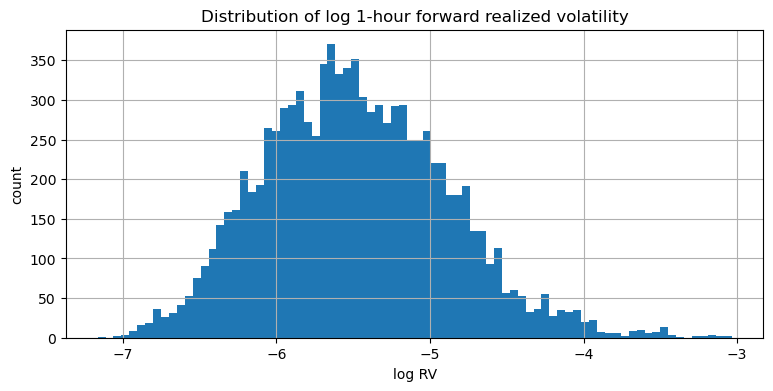

In [10]:

display(model_df["target_rv_1h"].describe(percentiles=[.01,.1,.5,.9,.99]))

plt.figure(figsize=(9,4))
model_df["target_log_rv_1h"].hist(bins=80)
plt.title("Distribution of log 1-hour forward realized volatility")
plt.xlabel("log RV")
plt.ylabel("count")
plt.show()



## 9. Purged expanding walk-forward validation

Because each label uses the **next hour**, training observations immediately before a test window can have labels overlapping the test period.

The last 12 training bars are therefore removed before each test window.


In [11]:

@dataclass
class Fold:
    fold: int
    train_idx: np.ndarray
    test_idx: np.ndarray


def make_walk_forward_folds(n_rows, n_splits, test_bars, min_train_bars, purge_bars):
    if n_rows < min_train_bars + test_bars + purge_bars:
        raise ValueError("Not enough rows for requested walk-forward setup.")

    max_possible = (n_rows - min_train_bars - purge_bars) // test_bars
    n_splits = min(n_splits, max_possible)
    if n_splits < 1:
        raise ValueError("No feasible test split.")

    first_test = n_rows - n_splits * test_bars
    folds = []

    for k in range(n_splits):
        test_start = first_test + k * test_bars
        test_end = min(test_start + test_bars, n_rows)
        train_end = test_start - purge_bars

        if train_end < min_train_bars:
            continue

        folds.append(
            Fold(
                fold=k+1,
                train_idx=np.arange(0, train_end),
                test_idx=np.arange(test_start, test_end),
            )
        )

    return folds


BARS_PER_DAY = 24 * 12

folds = make_walk_forward_folds(
    n_rows=len(model_df),
    n_splits=N_SPLITS,
    test_bars=TEST_DAYS * BARS_PER_DAY,
    min_train_bars=MIN_TRAIN_DAYS * BARS_PER_DAY,
    purge_bars=PURGE_BARS,
)

for f in folds:
    print(
        f"Fold {f.fold}: "
        f"train={model_df.index[f.train_idx[0]]} -> {model_df.index[f.train_idx[-1]]}; "
        f"test={model_df.index[f.test_idx[0]]} -> {model_df.index[f.test_idx[-1]]}"
    )


ValueError: Not enough rows for requested walk-forward setup.


## 10. Models

- **Persistence:** current trailing 1h RV predicts next 1h RV.
- **Ridge:** regularized linear benchmark.
- **GBT:** nonlinear thresholds/interactions.
- **MLP:** small nonlinear neural-network benchmark.

All ML models predict log RV and are evaluated after exponentiating back to the RV scale.


In [ ]:

class SmallMLP(nn.Module):
    def __init__(self, n_features: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def fit_mlp_predict(X_train, y_train, X_test):
    if not TORCH_AVAILABLE:
        raise RuntimeError("PyTorch is not installed.")

    n = len(X_train)
    val_size = max(int(0.15*n), min(1000, max(n//5, 1)))
    val_start = n - val_size
    inner_train_end = max(val_start - PURGE_BARS, 1)

    X_tr, y_tr = X_train[:inner_train_end], y_train[:inner_train_end]
    X_val, y_val = X_train[val_start:], y_train[val_start:]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr).astype("float32")
    X_val_s = scaler.transform(X_val).astype("float32")
    X_te_s = scaler.transform(X_test).astype("float32")

    train_loader = DataLoader(
        TensorDataset(
            torch.from_numpy(X_tr_s),
            torch.from_numpy(y_tr.astype("float32"))
        ),
        batch_size=MLP_BATCH_SIZE,
        shuffle=True,
    )

    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    model = SmallMLP(X_train.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=MLP_LR, weight_decay=1e-5)
    loss_fn = nn.MSELoss()

    Xv = torch.from_numpy(X_val_s).to(device)
    yv = torch.from_numpy(y_val.astype("float32")).to(device)

    best_state = None
    best_val = np.inf
    patience_left = MLP_PATIENCE

    for epoch in range(MLP_MAX_EPOCHS):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xv), yv).item()

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = MLP_PATIENCE
        else:
            patience_left -= 1
            if patience_left <= 0:
                break

    model.load_state_dict(best_state)
    model.to(device)
    model.eval()

    Xt = torch.from_numpy(X_te_s).to(device)
    with torch.no_grad():
        pred = model(Xt).cpu().numpy()

    return pred


def fit_predict_ridge(X_train, y_train, X_test):
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_train)
    Xte = scaler.transform(X_test)
    model = Ridge(alpha=RIDGE_ALPHA)
    model.fit(Xtr, y_train)
    return model.predict(Xte)


def fit_predict_gbt(X_train, y_train, X_test):
    model = HistGradientBoostingRegressor(**GBT_PARAMS)
    model.fit(X_train, y_train)
    return model.predict(X_test)


## 11. Run the benchmark

In [ ]:

def run_benchmark(df, features, folds):
    records = []

    for f in folds:
        train = df.iloc[f.train_idx]
        test = df.iloc[f.test_idx]

        Xtr = train[features].to_numpy(dtype=float)
        Xte = test[features].to_numpy(dtype=float)
        ytr = train["target_log_rv_1h"].to_numpy(dtype=float)

        out = pd.DataFrame(index=test.index)
        out["fold"] = f.fold
        out["actual_rv"] = test["target_rv_1h"]
        out["actual_var"] = test["target_var_1h"]
        out["rv_24h_state"] = test["rv_24h"]
        out["target_rv_train_median"] = train["target_rv_1h"].median()

        q30, q70 = train["rv_24h"].quantile([0.30, 0.70]).values
        out["regime"] = pd.cut(
            out["rv_24h_state"],
            bins=[-np.inf, q30, q70, np.inf],
            labels=["low","medium","high"],
        ).astype(str)

        out["pred_persistence"] = test["rv_1h"].clip(lower=EPS)

        ridge_log = fit_predict_ridge(Xtr, ytr, Xte)
        gbt_log = fit_predict_gbt(Xtr, ytr, Xte)

        out["pred_ridge"] = np.exp(ridge_log).clip(min=EPS)
        out["pred_gbt"] = np.exp(gbt_log).clip(min=EPS)

        if RUN_MLP and TORCH_AVAILABLE:
            mlp_log = fit_mlp_predict(Xtr, ytr, Xte)
            out["pred_mlp"] = np.exp(mlp_log).clip(min=EPS)

        records.append(out)
        print(f"Finished fold {f.fold}/{len(folds)}")

    return pd.concat(records).sort_index()


preds = run_benchmark(model_df, FULL_FEATURES, folds)
display(preds.head())
print(preds.shape)



## 12. Forecast metrics

For QLIKE, use realized variance \(v_t\) and forecast variance \(\hat v_t=\hat\sigma_t^2\):

\[
QLIKE_t=
\frac{v_t}{\hat v_t}
-\log\left(\frac{v_t}{\hat v_t}\right)-1.
\]

Lower is better.


In [ ]:

def qlike(actual_var, pred_rv):
    actual_var = np.asarray(actual_var, dtype=float)
    pred_var = np.asarray(pred_rv, dtype=float) ** 2
    ratio = np.clip(actual_var, EPS, None) / np.clip(pred_var, EPS, None)
    return np.mean(ratio - np.log(ratio) - 1.0)


def evaluate_predictions(pred_df):
    rows = []
    for c in [c for c in pred_df.columns if c.startswith("pred_")]:
        y = pred_df["actual_rv"].to_numpy()
        p = pred_df[c].to_numpy()
        rows.append({
            "model": c.replace("pred_", ""),
            "RMSE": mean_squared_error(y, p) ** 0.5,
            "MAE": mean_absolute_error(y, p),
            "QLIKE": qlike(pred_df["actual_var"], p),
        })
    return pd.DataFrame(rows).sort_values("QLIKE")


metrics_table = evaluate_predictions(preds)
display(metrics_table)

metrics_table.to_csv(OUTPUT_DIR / "model_metrics.csv", index=False)
preds.to_csv(OUTPUT_DIR / "oos_predictions.csv")

plt.figure(figsize=(8,4))
metrics_table.set_index("model")["RMSE"].plot(kind="bar")
plt.title("OOS RMSE by model")
plt.ylabel("RMSE")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(8,4))
metrics_table.set_index("model")["QLIKE"].plot(kind="bar")
plt.title("OOS QLIKE by model")
plt.ylabel("QLIKE (lower is better)")
plt.xticks(rotation=0)
plt.show()


### Short OOS forecast plot

In [ ]:

plot_cols = ["actual_rv","pred_persistence","pred_ridge","pred_gbt"]
if "pred_mlp" in preds.columns:
    plot_cols.append("pred_mlp")

sample = preds[plot_cols].iloc[-7 * BARS_PER_DAY:]

plt.figure(figsize=(12,5))
for c in sample.columns:
    plt.plot(sample.index, sample[c], label=c, linewidth=1)
plt.title("Last 7 days of OOS 1-hour realized-volatility forecasts")
plt.legend()
plt.xticks(rotation=30)
plt.show()



## 13. Feature-group ablation

This tests **incremental information** directly:

- `H`: historical only;
- `H+M`: historical + microstructure;
- `H+D`: historical + derivatives;
- `H+M+D`: full set.


In [ ]:

ABLATION_SETS = {
    "H": H_FEATURES,
    "H+M": H_FEATURES + M_FEATURES,
    "H+D": H_FEATURES + D_FEATURES,
    "H+M+D": H_FEATURES + M_FEATURES + D_FEATURES,
}


def run_gbt_ablation(df, folds, sets):
    rows = []

    for name, features in sets.items():
        if not features:
            continue

        fold_preds = []
        for f in folds:
            tr = df.iloc[f.train_idx]
            te = df.iloc[f.test_idx]

            model = HistGradientBoostingRegressor(**GBT_PARAMS)
            model.fit(
                tr[features].to_numpy(dtype=float),
                tr["target_log_rv_1h"].to_numpy(dtype=float),
            )

            pred_rv = np.exp(
                model.predict(te[features].to_numpy(dtype=float))
            ).clip(min=EPS)

            fold_preds.append(pd.DataFrame({
                "actual_rv": te["target_rv_1h"].values,
                "actual_var": te["target_var_1h"].values,
                "pred_rv": pred_rv,
            }, index=te.index))

        p = pd.concat(fold_preds).sort_index()
        rows.append({
            "feature_set": name,
            "n_features": len(features),
            "RMSE": mean_squared_error(p["actual_rv"], p["pred_rv"]) ** 0.5,
            "MAE": mean_absolute_error(p["actual_rv"], p["pred_rv"]),
            "QLIKE": qlike(p["actual_var"], p["pred_rv"]),
        })

    return pd.DataFrame(rows).sort_values("QLIKE")


ablation = run_gbt_ablation(model_df, folds, ABLATION_SETS)
display(ablation)
ablation.to_csv(OUTPUT_DIR / "gbt_feature_ablation.csv", index=False)

plt.figure(figsize=(8,4))
ablation.set_index("feature_set")["QLIKE"].plot(kind="bar")
plt.title("GBT feature-group ablation: OOS QLIKE")
plt.ylabel("QLIKE (lower is better)")
plt.xticks(rotation=0)
plt.show()



## 14. Volatility-regime diagnostics

Regimes are defined with **training-sample** 30th/70th percentiles of trailing 24h RV inside each fold.

Because absolute RMSE naturally rises in high-volatility periods, also examine the relative gain over persistence:

\[
1-\frac{RMSE_{model}}{RMSE_{baseline}}.
\]


In [ ]:

def regime_table(pred_df, model_col="pred_gbt"):
    rows = []
    for regime, g in pred_df.groupby("regime", observed=True):
        base_rmse = mean_squared_error(g["actual_rv"], g["pred_persistence"]) ** 0.5
        model_rmse = mean_squared_error(g["actual_rv"], g[model_col]) ** 0.5
        rows.append({
            "regime": regime,
            "n": len(g),
            "baseline_RMSE": base_rmse,
            "model_RMSE": model_rmse,
            "relative_RMSE_gain": 1 - model_rmse/base_rmse,
            "model_QLIKE": qlike(g["actual_var"], g[model_col]),
        })

    order = pd.CategoricalDtype(["low","medium","high"], ordered=True)
    out = pd.DataFrame(rows)
    out["regime"] = out["regime"].astype(order)
    return out.sort_values("regime")


regime_diag = regime_table(preds, "pred_gbt")
display(regime_diag)
regime_diag.to_csv(OUTPUT_DIR / "regime_diagnostics_gbt.csv", index=False)

plt.figure(figsize=(8,4))
regime_diag.set_index("regime")["relative_RMSE_gain"].plot(kind="bar")
plt.axhline(0, linewidth=1)
plt.title("GBT relative RMSE improvement vs persistence by regime")
plt.ylabel("1 - RMSE_GBT / RMSE_baseline")
plt.xticks(rotation=0)
plt.show()



## 15. Economic-value illustration: volatility targeting

This is **not directional alpha**. The forecast changes exposure, not direction.

\[
w_t=
\min\left(
w_{\max},
\frac{\sigma^*_t}{\hat\sigma_t}
\right).
\]

The position chosen at \(t\) is applied to the **next** 5-minute return, and a simple turnover-proportional transaction cost is subtracted.


In [ ]:

def backtest_vol_target(
    full_df,
    pred_df,
    pred_col,
    cost_bps=TRANSACTION_COST_BPS,
    max_leverage=MAX_LEVERAGE,
):
    bt = pred_df[[pred_col, "target_rv_train_median"]].copy()
    bt["next_ret_5m"] = full_df["ret_5m"].shift(-1).reindex(bt.index)

    raw_w = bt["target_rv_train_median"] / bt[pred_col].clip(lower=EPS)
    bt["weight"] = raw_w.clip(lower=0, upper=max_leverage)

    bt["turnover"] = bt["weight"].diff().abs().fillna(bt["weight"].abs())
    bt["gross_ret"] = bt["weight"] * bt["next_ret_5m"]
    bt["cost"] = (cost_bps / 1e4) * bt["turnover"]
    bt["net_ret"] = bt["gross_ret"] - bt["cost"]
    bt = bt.dropna()

    periods_per_year = 365 * 24 * 12
    mu = bt["net_ret"].mean()
    sd = bt["net_ret"].std(ddof=1)

    stats = {
        "model": pred_col.replace("pred_", ""),
        "mean_weight": bt["weight"].mean(),
        "mean_turnover_5m": bt["turnover"].mean(),
        "annualized_sharpe": np.sqrt(periods_per_year) * mu/sd if sd > 0 else np.nan,
        "total_log_return_approx": bt["net_ret"].sum(),
        "annualized_vol": np.sqrt(periods_per_year) * sd,
    }
    return bt, stats


bt_results, bt_stats = {}, []

for c in [c for c in preds.columns if c.startswith("pred_")]:
    bt, st = backtest_vol_target(model_df, preds, c)
    bt_results[c] = bt
    bt_stats.append(st)

bt_stats = pd.DataFrame(bt_stats)
display(bt_stats)
bt_stats.to_csv(OUTPUT_DIR / "vol_target_stats.csv", index=False)

plt.figure(figsize=(11,5))
for c, bt in bt_results.items():
    curve = bt["net_ret"].cumsum()
    plt.plot(curve.index, curve.values, label=c.replace("pred_", ""))
plt.title(f"Illustrative volatility-targeting cumulative log return (cost={TRANSACTION_COST_BPS:.1f} bps)")
plt.legend()
plt.xticks(rotation=30)
plt.show()



## 16. Interview-ready factual summary

Run this cell after the experiment. It prints the actual ranking and percentage improvements, so you can report real results rather than inventing numbers.


In [ ]:

def pct_improvement(new_loss, baseline_loss):
    return 100 * (baseline_loss - new_loss) / baseline_loss

m = metrics_table.set_index("model")

print("=== MODEL COMPARISON ===")
display(metrics_table)

if "persistence" in m.index:
    base = m.loc["persistence"]
    for model in [x for x in ["ridge","gbt","mlp"] if x in m.index]:
        print(
            f"{model:>11s}: "
            f"RMSE improvement vs persistence = "
            f"{pct_improvement(m.loc[model,'RMSE'], base['RMSE']):.2f}% | "
            f"QLIKE improvement = "
            f"{pct_improvement(m.loc[model,'QLIKE'], base['QLIKE']):.2f}%"
        )

print("\n=== FEATURE ABLATION (GBT) ===")
display(ablation)

print("\n=== REGIME DIAGNOSTICS (GBT) ===")
display(regime_diag)

print("\n=== VOL-TARGET ILLUSTRATION ===")
display(bt_stats)



## 17. Best robustness checks if time allows

Prefer a few targeted checks over dozens of specifications:

1. **Non-overlapping labels:** forecast only once per hour.
2. **Alternative RV sampling:** compare 5-minute and 10-minute construction.
3. **Mid-price vs trade-price RV:** if top-of-book history is complete enough.
4. **Rolling vs expanding training window.**
5. **Funding/OI removal:** does derivatives information still improve OOS loss?
6. **Stress-event exclusion:** is the result driven by one extreme episode?

Do not repeatedly tune the final OOS period.



## 18. Data caveats

- Binance Vision archives can contain missing/revised files.
- Historical `bookTicker` is much heavier than Klines/OI/Funding.
- `bookDepth` \(\pm1\%\) OBI is an aggregated depth-band imbalance, not exact top-of-book OBI.
- Historical open-interest REST endpoints expose only a limited recent window; this notebook therefore uses historical `metrics` archives.
- Always inspect timestamp coverage and missingness before interpreting model results.

Outputs are saved under `btc_vol_project_outputs/`.
